## Purpose of the Interactive Notebook

The `TOAD_Amazon_interactive.ipynb` is an interactive sandbox that allows you to:
- **Select different models and variables** and see results immediately
- **Tune TOAD parameters** (shift detection, clustering) while observing the effects
- **Explore the TOAD pipeline** step-by-step for learning and debugging

### Quick Start Guide

**Step 1: Choose a variable**
```python
MODEL = "TaiESM1"
VARIABLE = "cVeg"  # Options: cVeg, MCWD, fFire, grassFrac, treeFrac, AnnualRainfall
ROLLING_YEARS = 1  # Options: 1 (annual), 5 (5-year smooth), 10 (10-year smooth)
```

**Step 2: Load and explore data**
- Run Cells to load the preprocessed .nc file
- View preprocessing results: trend plot and spatial distribution

**Step 3: Detect shifts**
- Adjust `window_indices`, `min_abs_change`, `min_rel_change` to tune sensitivity

**Step 4: Cluster shifts**
- Run Cells for basic clustering with fixed parameters
- Run Cells for optimized clustering 

In [19]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
import os
from pathlib import Path

# Automatically find Amazon/ directory regardless of where notebook is opened from
current_dir = Path.cwd()
if current_dir.name == "docs":
    amazon_dir = current_dir.parent
else:
    # Search for Amazon directory up the tree
    amazon_dir = current_dir
    while amazon_dir.name != "Amazon" and amazon_dir.parent != amazon_dir:
        amazon_dir = amazon_dir.parent
    if amazon_dir.name != "Amazon":
        amazon_dir = current_dir / ".." / "Amazon"

amazon_dir = amazon_dir.resolve()
print(f"Working from Amazon directory: {amazon_dir}")

# Ensure Amazon directory is in sys.path for imports
if str(amazon_dir) not in sys.path:
    sys.path.insert(0, str(amazon_dir))

Working from Amazon directory: /Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon


### 1. Load preprocessed model data
When you change the model and variable, you can see different result automatically!

In [20]:
MODEL = "GFDL-ESM4"
VARIABLE = "treeFrac"
ROLLING_YEARS = 1
# ROLLING_YEARS = 1   # annual
# ROLLING_YEARS = 5    # 5-year centered rolling mean
# ROLLING_YEARS = 10   # 10-year centered rolling mean

SHIFT_DIRECTION = "negative"
# SHIFT_DIRECTION = "positive"  # increasing shifts, e.g. grassFrac, fFire
# SHIFT_DIRECTION = "negative"  # decreasing shifts, e.g. cVeg, treeFrac, MCWD, AnnualRainfall

def smoothing_suffix(rolling_years=None):
    if rolling_years is None or rolling_years <= 1:
        return ""
    return f"_smooth{rolling_years}yr"


def get_plot_path(plot_type, model_name, variable, rolling_years=None):
    suffix = smoothing_suffix(rolling_years)

    filename_map = {
        "trend": f"TrendPlot_{variable}_{model_name}{suffix}.png",
        "spatial": f"SpatialMap_{variable}_{model_name}{suffix}.png",
    }

    return amazon_dir / "plots" / model_name / filename_map[plot_type]

suffix = smoothing_suffix(ROLLING_YEARS)

# Use absolute paths
file_path = amazon_dir / f"processed_data/{MODEL}/TOAD_{VARIABLE}_{MODEL}{suffix}.nc"
print(f"Loading: {file_path}")

Loading: /Users/kim-wonjin/Documents/CLEWS/Python/TOAD_CLEWS/Amazon/processed_data/GFDL-ESM4/TOAD_treeFrac_GFDL-ESM4.nc


In [21]:
# Open the processed dataset(netCDF)
ds = xr.open_dataset(file_path)

#### check resolution of model output

In [22]:
print("source_id:", ds.attrs.get("source_id"))
print("experiment_id:", ds.attrs.get("experiment_id"))
print("variant_label:", ds.attrs.get("variant_label"))
print("First time:", ds["time"].values[0])
print("Last time:", ds["time"].values[-1])
nominal_res = ds.attrs.get("nominal_resolution", "Not Available")
print("Spatial resolution:", f"Nominal Resolution: {nominal_res}")

source_id: GFDL-ESM4
experiment_id: 1pctCO2
variant_label: r1i1p1f1
First time: 0001-01-01 00:00:00
Last time: 0150-01-01 00:00:00
Spatial resolution: Nominal Resolution: 100 km


Annual average, with GWL dataset : `Variable you chose` : (GWL, lat, lon)

this data have annual average of variable in each grid in Amazon area.

#### Plot and check data

##### (1) Average Trend of Variable in all amazon area

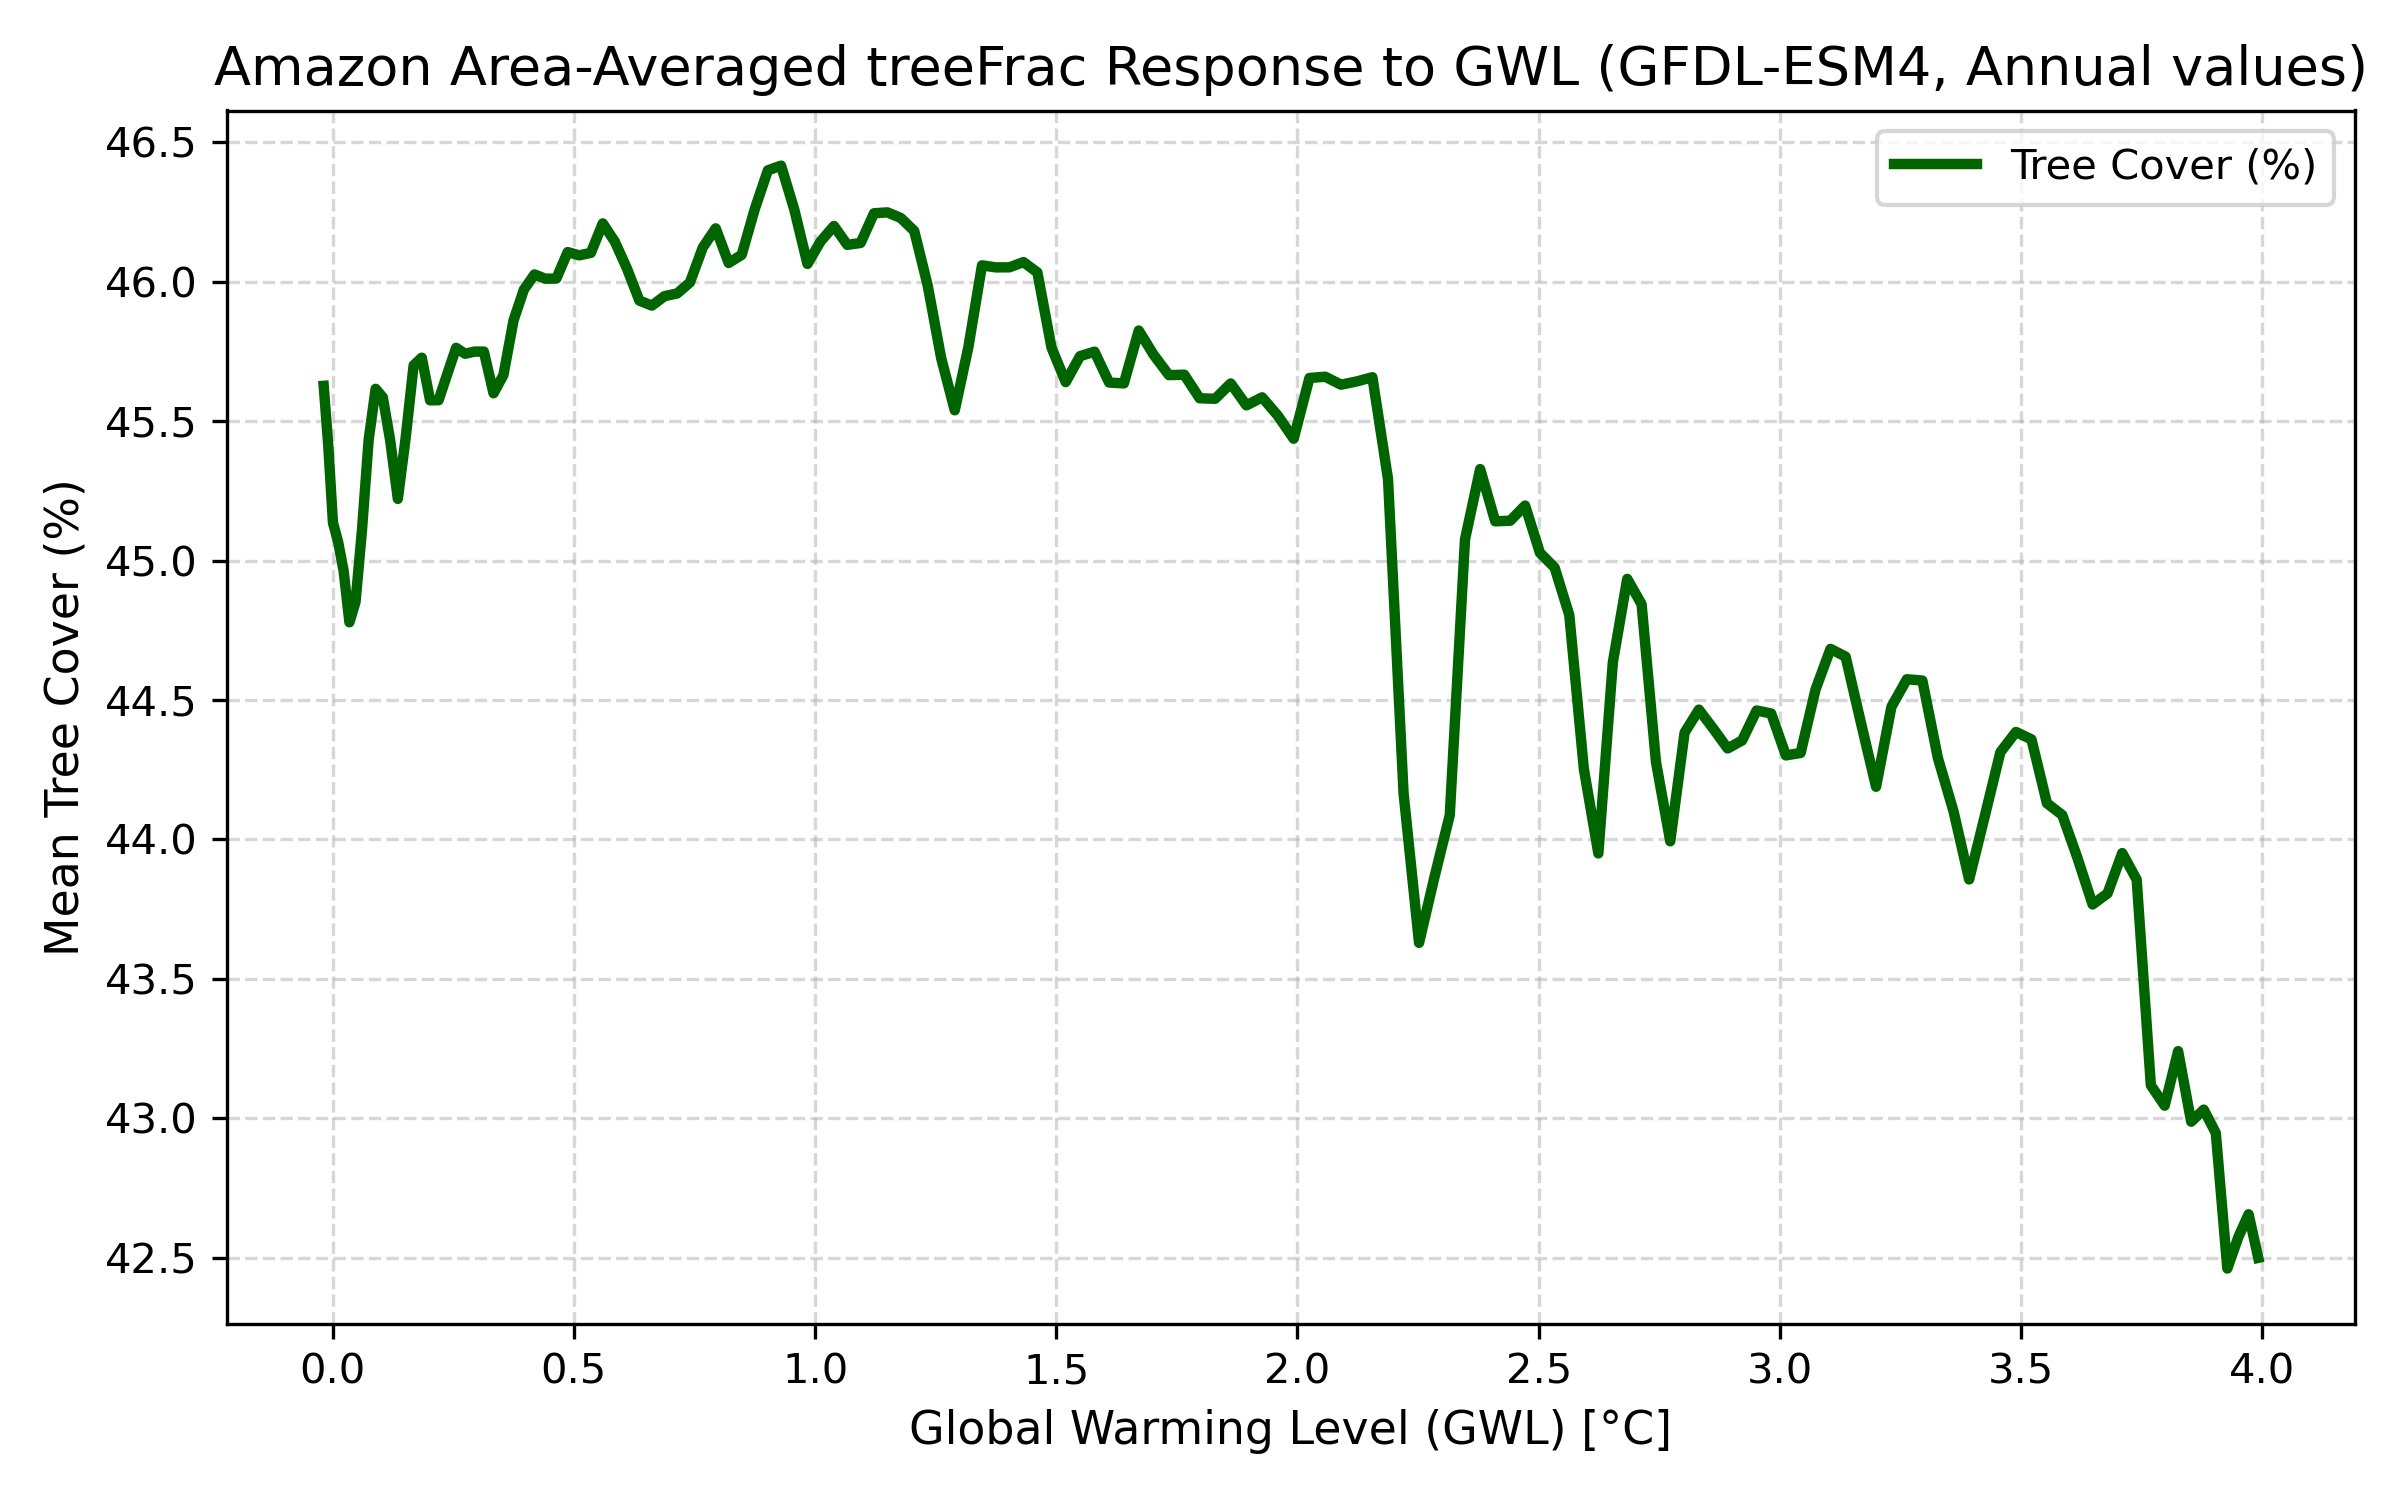

In [23]:
from IPython.display import Image, display

trend_path = amazon_dir / f"plots/{MODEL}/TrendPlot_{VARIABLE}_{MODEL}{suffix}.png"

# show image
display(Image(filename=str(trend_path)))

##### (2) Spatial Distribution by different Global Warming Level

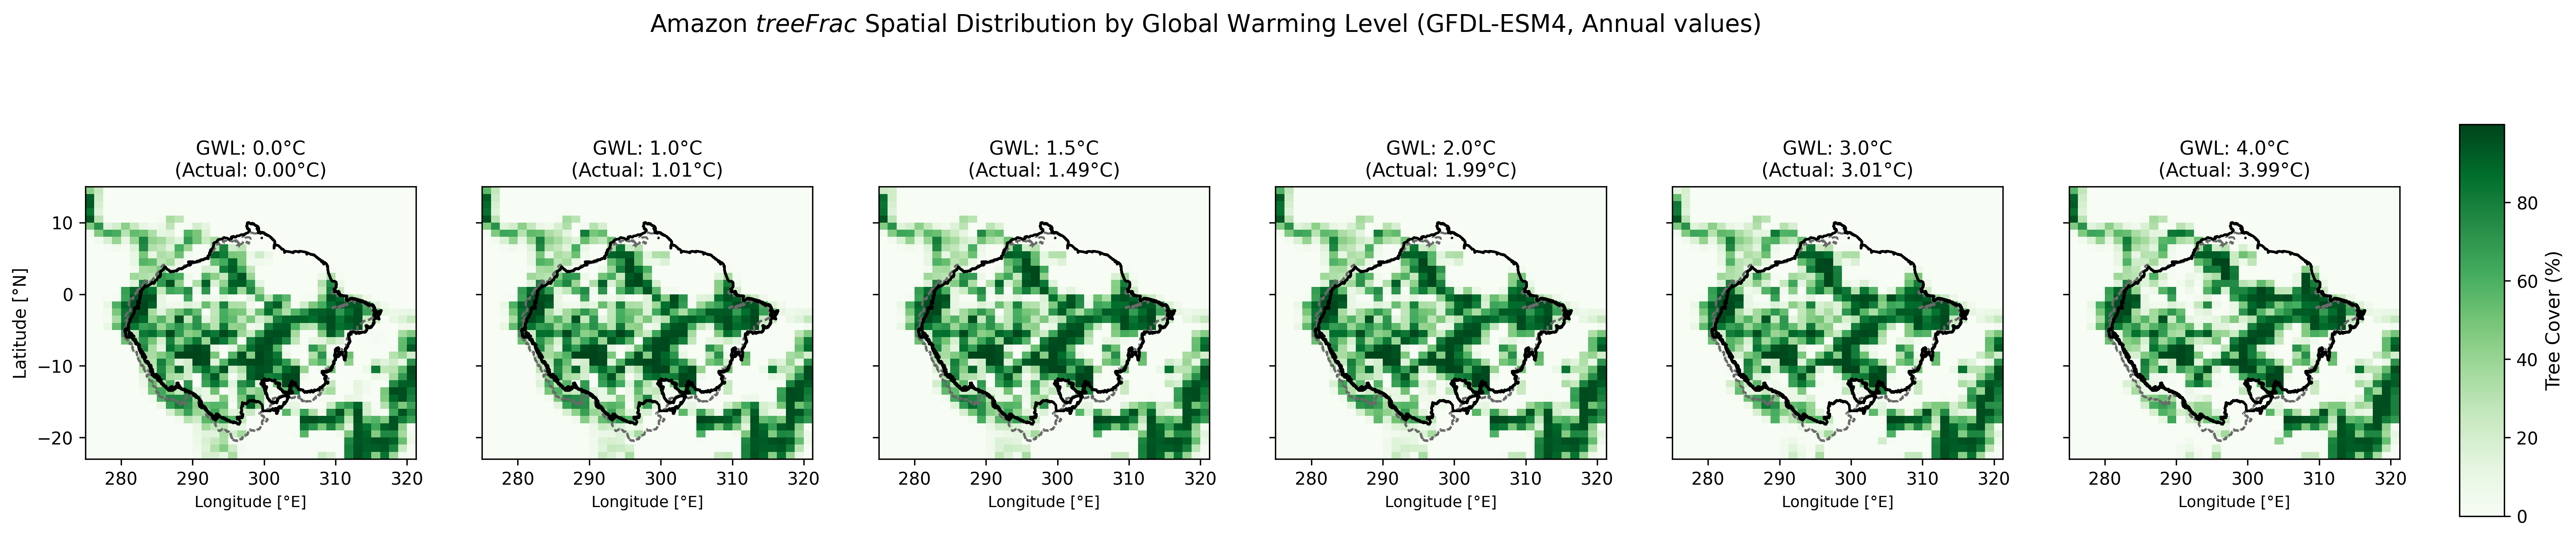

In [24]:
spatial_path = amazon_dir / f"plots/{MODEL}/SpatialMap_{VARIABLE}_{MODEL}{suffix}.png"

# show image
display(Image(filename=str(spatial_path)))

### Start TOAD

In [26]:
import sys
import os

# Add Amazon directory to path (already done in prerequisites)
from toad import TOAD

td = TOAD(ds, time_dim="GWL")

### Step 1: Compute shifts


In [62]:
# Add Amazon directory to path (already set up in prerequisites)
from custom_shift_method import FilteredASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

cveg_method = FilteredASDETECT(
    window_indices=30,       # 15 years before and after
    min_abs_change=5.0,      # at least 2 kgC/m2 absolute change
    min_rel_change=0.25      # at least 25% relative change
)

# define variable and method
td.compute_shifts(var=VARIABLE, method=cveg_method)
# ~3m 15s

Shift detection (1406 grid cells in 22 blocks):   0%|          | 0/22 [00:00<?, ?it/s]

INFO: New shifts variable treeFrac_dts: min/mean/max=-0.989/-0.006/0.989 using 965 grid cells. Skipped 31.4% grid cells: 0 NaN, 441 constant.


In [28]:
# from toad.shifts import ASDETECT

# # the test data already contains computed shifts, so let's just drop them
# td.drop_shifts()

# # define variable and method
# td.compute_shifts(var=VARIABLE, method=ASDETECT())
# # ~12 seconds

### Show all detected abrupt shifts

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Maximum shift magnitude for treeFrac'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

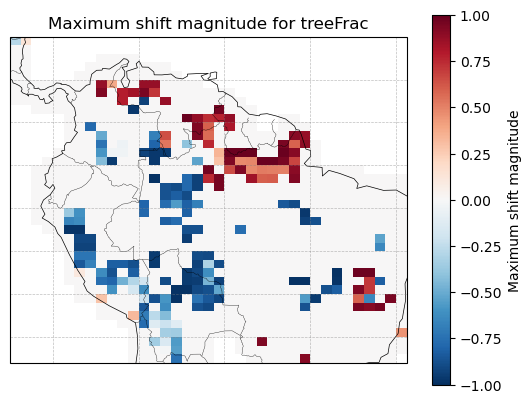

In [63]:
td.plot.max_shift_map()

##### Show shifts satisfying `shift_magnitude_threshold` and `shift_direction`

(<Figure size 640x480 with 2 Axes>,
 <GeoAxes: title={'center': 'Time of maximum shift for treeFrac'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

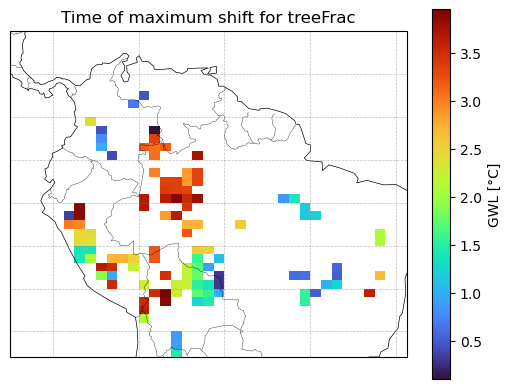

In [64]:
td.plot.time_of_max_shift_map(shift_direction=SHIFT_DIRECTION, shift_threshold=0.5)
# where abs(shift) > shift_threshold.

#### Check the single grid - detected series

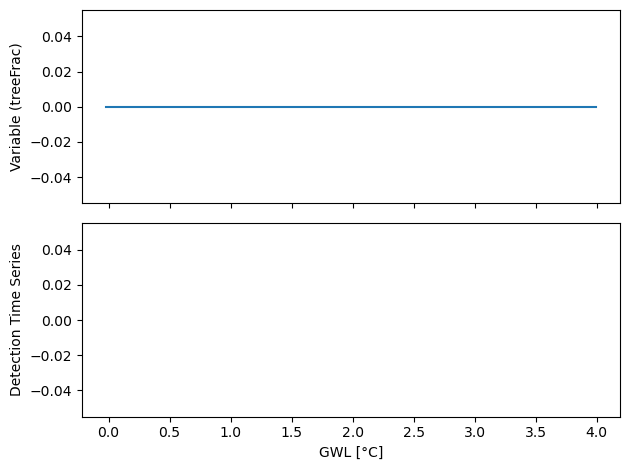

In [65]:
fig, axs = plt.subplots(2, sharex=True)
target_lon = 305.0  # e.g., 300°E
target_lat = 5.0   # e.g., 5°S

td.data[VARIABLE].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[0])
td.data[f"{VARIABLE}_dts"].sel(lon=target_lon, lat=target_lat, method="nearest").plot(ax=axs[1])

axs[0].set_ylabel(f"Variable ({VARIABLE})")
axs[1].set_ylabel("Detection Time Series")
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_xlabel("")
fig.tight_layout()

### Clustering-Single(not optmized)

Basically, all clustering apply filter : `DEFAULT_SHIFT_THRESHOLD`: float = 0.5.

it means, only filter detected shifts whose absolute magnitude are larger than 0.5

In [70]:
from toad.clustering.methods.space_time_dbscan import SpaceTimeDBSCAN
td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    method=SpaceTimeDBSCAN(
        spatial_eps=600,  # km 
        temporal_eps=1.0,  # units of the time variable -> our time steps is 'GWL" degree 
        min_samples=15 # 15~55
    ),
    shift_direction=SHIFT_DIRECTION
)

INFO: New cluster variable treeFrac_dts_cluster: Identified 2 clusters in 117 pts; Left 55.6% as noise (65 pts).


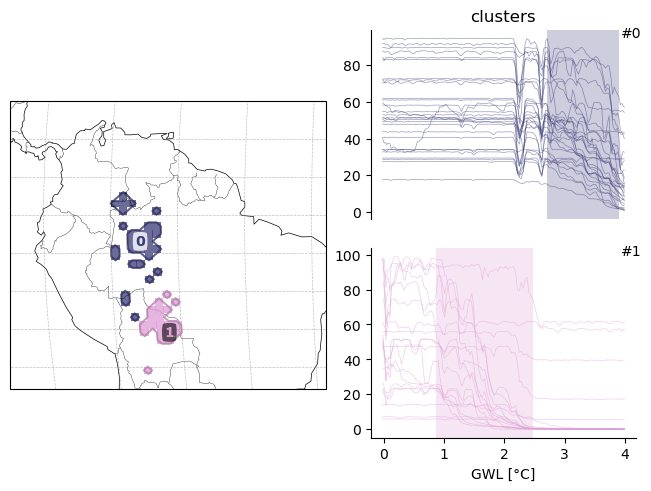

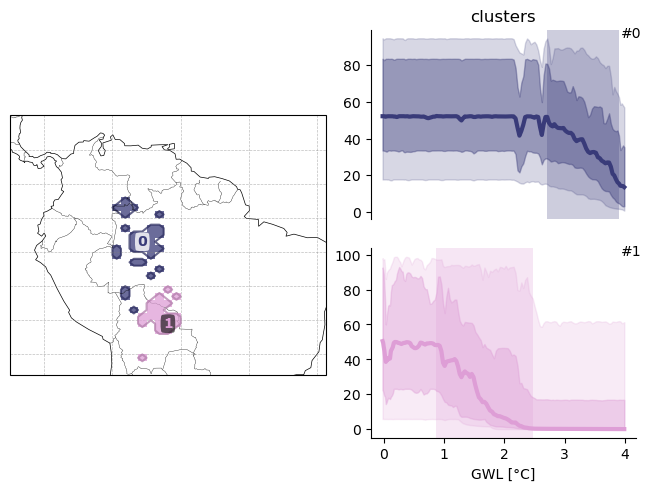

Exception ignored in: <function ResourceTracker.__del__ at 0x1075e5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106621b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102eddb20>
Traceback (most recent call last

In [ ]:
td.plot.overview(map_style={"projection": "global"});
td.plot.overview(mode="aggregated");

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import preprocess
from matplotlib.cm import get_cmap


def plot_3d_spatiotemporal_clusters(
    td,
    var="cVeg",
    view_angle=(30, -60),
):

    # ---------------------------------------------------
    # Extract TOAD results
    # ---------------------------------------------------
    # NOTE: previously this recomputed the GWL (z) values via
    # td.stats(var).time.compute_transition_time(shift_direction=...),
    # which always uses the library default shift_threshold=0.5 -- NOT
    # necessarily the threshold actually used in compute_clusters() (e.g.
    # a custom "shift_threshold" from config.json). Any grid cell whose
    # cluster membership was determined with a different threshold but
    # whose shift magnitude fell below 0.5 got transition_time=NaN and was
    # silently dropped by valid_mask below -- causing some clusters to be
    # missing or under-represented (and effectively look like a color
    # legend issue) in the plot.
    #
    # Fix: derive lon/lat/GWL directly from clusters_3d itself -- the
    # array TOAD already fills in during compute_clusters() (NaN for
    # points never considered, a real label incl. -1 for noise for every
    # point that WAS a candidate). This guarantees the plotted GWL always
    # corresponds 1:1 with the actual cluster label, regardless of which
    # shift_threshold was used, and naturally plots every qualifying
    # point per cell (not just one via a lossy .max(dim=time) collapse).

    time_dim = td.time_dim
    clusters_3d = td.get_clusters(var)

    # Broadcast lon/lat/GWL coordinates to the same shape as clusters_3d so
    # every entry lines up 1:1 with its cluster label. clusters_3d itself
    # must be included in the broadcast call (and used from its output,
    # not the original) -- xr.broadcast does not guarantee its outputs
    # share clusters_3d's own dimension order otherwise, which would
    # silently misalign cluster_vals against lon/lat/gwl_vals after
    # flattening.
    clusters_3d, lon_3d, lat_3d, gwl_3d = xr.broadcast(
        clusters_3d, clusters_3d["lon"], clusters_3d["lat"], clusters_3d[time_dim]
    )

    cluster_vals = clusters_3d.values.flatten()
    lon_vals = lon_3d.values.flatten()
    lat_vals = lat_3d.values.flatten()
    gwl_vals = gwl_3d.values.flatten()

    # Convert longitude from 0-360 to -180-180
    lon_vals = np.where(lon_vals > 180, lon_vals - 360, lon_vals)

    # Only points that were actually assigned a label (including -1 for
    # noise) during compute_clusters() are non-NaN here.
    valid_mask = ~np.isnan(cluster_vals)

    gwl_valid = gwl_vals[valid_mask]
    lon_valid = lon_vals[valid_mask]
    lat_valid = lat_vals[valid_mask]
    cluster_valid = cluster_vals[valid_mask]

    # ---------------------------------------------------
    # Figure
    # ---------------------------------------------------

    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection="3d")

    cmap = get_cmap("tab10")

    # ---------------------------------------------------
    # Determine floor height
    # ---------------------------------------------------

    z_floor = np.nanmin(gwl_valid) - 0.2

    # ---------------------------------------------------
    # Plot faint projection on floor
    # ---------------------------------------------------

    ax.scatter(
        lon_valid,
        lat_valid,
        np.full_like(gwl_valid, z_floor),
        c="lightgray",
        s=6,
        alpha=0.15,
        depthshade=False,
    )

    # ---------------------------------------------------
    # Noise
    # ---------------------------------------------------

    noise_mask = cluster_valid == -1

    ax.scatter(
        lon_valid[noise_mask],
        lat_valid[noise_mask],
        gwl_valid[noise_mask],
        c="gray",
        s=70,
        alpha=0.5,
        depthshade=False,
        label="Unclustered (Noise)",
    )

    # ---------------------------------------------------
    # Clusters
    # ---------------------------------------------------

    unique_clusters = np.unique(cluster_valid[~noise_mask])

    for i, cid in enumerate(unique_clusters):

        mask = cluster_valid == cid

        ax.scatter(
            lon_valid[mask],
            lat_valid[mask],
            gwl_valid[mask],
            color=cmap(i % 10),
            s=70,
            edgecolor="black",
            linewidth=0.4,
            alpha=0.95,
            depthshade=False,
            label=f"Cluster #{int(cid)}",
        )

    # ---------------------------------------------------
    # Amazon biome + basin boundary (reference outlines only,
    # not used for masking -- see preprocess.load_boundary_shapefiles)
    # ---------------------------------------------------

    biome_gdf, basin_gdf = preprocess.load_boundary_shapefiles()

    for gdf, color, linestyle, linewidth in [
        (basin_gdf, "dimgray", "--", 1.2),
        (biome_gdf, "black", "-", 1.5),
    ]:
        for geom in gdf.geometry:
            polygons = [geom] if geom.geom_type == "Polygon" else geom.geoms
            for poly in polygons:
                x, y = poly.exterior.xy
                ax.plot(
                    np.asarray(x),
                    np.asarray(y),
                    zs=z_floor,
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                    alpha=0.8,
                )

    # ---------------------------------------------------
    # Axis settings
    # ---------------------------------------------------

    # Derived from the actual plotted data extent (with a small pad)
    # rather than a hardcoded box, so this stays correct if the pipeline's
    # spatial domain changes (see preprocess.compute_buffered_bbox).
    lon_pad, lat_pad = 2.0, 2.0
    ax.set_xlim(np.nanmin(lon_valid) - lon_pad, np.nanmax(lon_valid) + lon_pad)
    ax.set_ylim(np.nanmin(lat_valid) - lat_pad, np.nanmax(lat_valid) + lat_pad)

    ax.set_zlim(
        np.nanmin(gwl_valid) - 0.2,
        np.nanmax(gwl_valid) + 0.2,
    )

    # Make the box visually balanced
    ax.set_box_aspect((1.35, 1.0, 1.1))

    ax.set_xlabel("Longitude", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_ylabel("Latitude", fontsize=11, fontweight="bold", labelpad=10)
    ax.set_zlabel("Global Warming Level (\u00b0C)", fontsize=11, fontweight="bold", labelpad=12)

    ax.set_title(
        f"3D Spatiotemporal Clustering of {var} Abrupt Shifts",
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    ax.view_init(
        elev=view_angle[0],
        azim=view_angle[1],
    )

    # Light grid
    ax.grid(True, alpha=0.3)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Cluster Groups",
        frameon=True,
    )

    plt.tight_layout()
    plt.show()

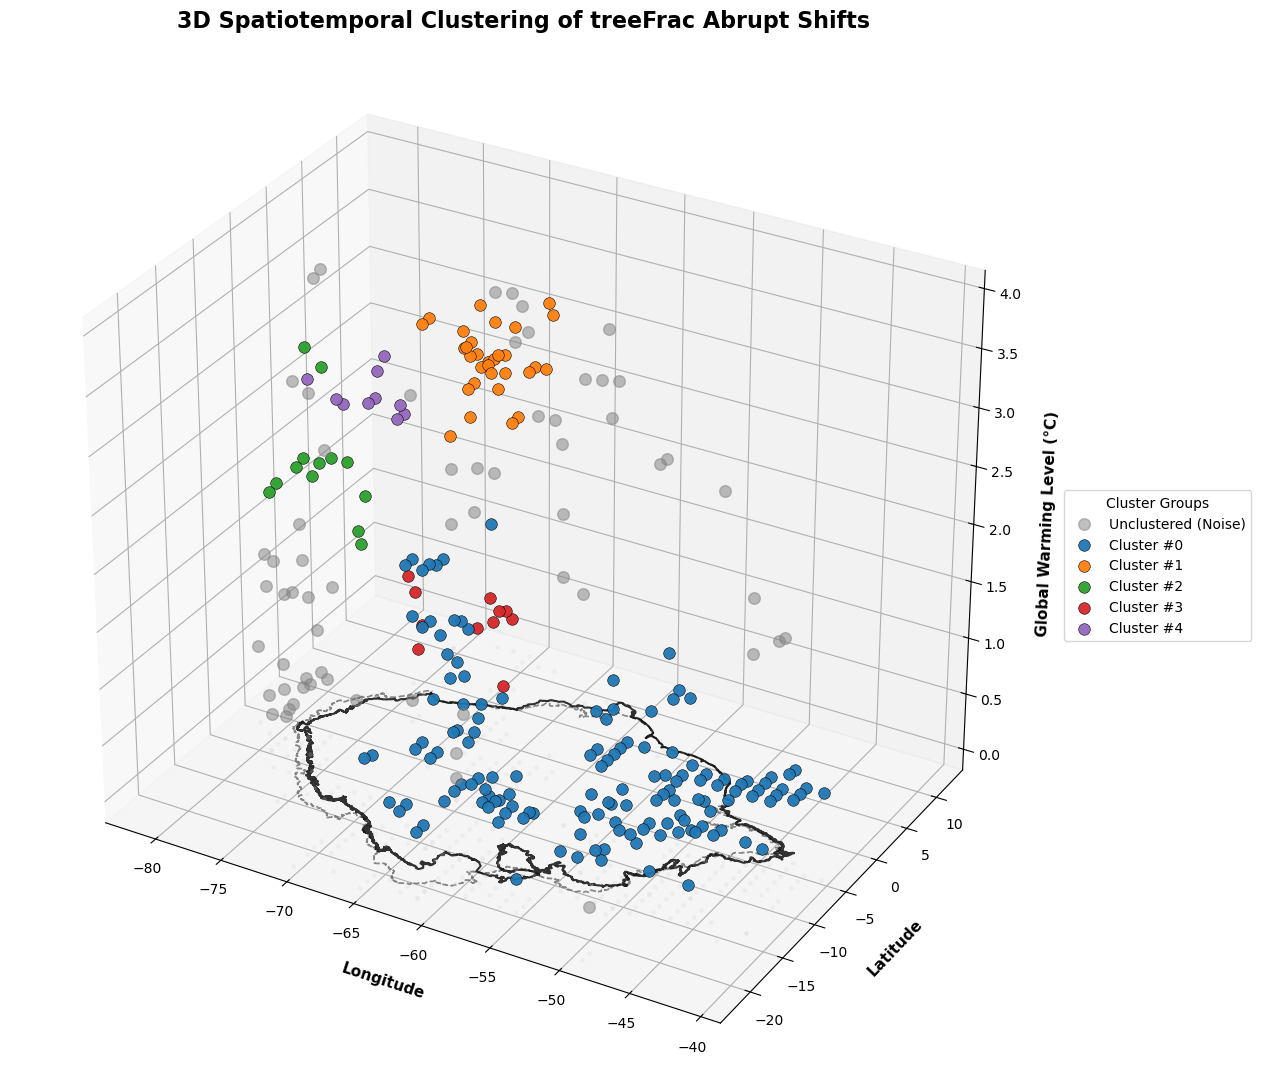

In [35]:
plot_3d_spatiotemporal_clusters(td, var=VARIABLE)

### Optimized Clustering - with parameter setting

INFO: optimizing 500 trials with params: {'spatial_eps': (100.0, 800.0), 'temporal_eps': (0.2, 1.5), 'min_samples': (10, 30)}


  0%|          | 0/500 [00:00<?, ?it/s]

INFO: Ran 500 trials in 11.32 seconds. Best (#313): score 0.9058, params {'spatial_eps': 416.50922280427835, 'temporal_eps': 0.2241895073705795, 'min_samples': 13}. 
INFO: New cluster variable treeFrac_dts_cluster: Identified 1 cluster in 272 pts; Left 89.3% as noise (243 pts).


(<Figure size 640x480 with 2 Axes>,
 {'map': <GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>,
  'timeseries': [<Axes: title={'center': 'clusters in Tree Cover Fraction [%]'}, xlabel='GWL [°C]'>]})

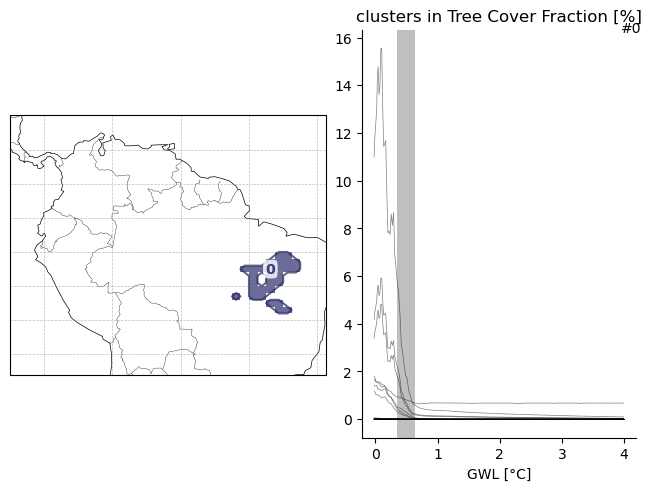

In [61]:
td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    var=VARIABLE,
    method=SpaceTimeDBSCAN,
    shift_direction=SHIFT_DIRECTION,
    shift_selection="local",

    optimize=True,
    optimize_params={
        "spatial_eps": (100.0, 800.0),   # km
        "temporal_eps": (0.2, 1.5),       # °C GWL
        "min_samples": (10, 30),            # integer
    },

    optimize_objective="combined_spatial_nonlinearity",
    optimize_direction="maximize",
    optimize_n_trials=500,
    overwrite=True,
)

# plot the latest cluster variable
# td.plot.overview(td.cluster_vars[-1], normalize="max_each"); normalisation the y-axis 
td.plot.overview(td.cluster_vars[-1])

In [37]:
td

In [38]:
# You can find all method parameters used for the computation in the attributes, e.g:
getattr(td.data, f"{VARIABLE}_dts").attrs

{'long_name': 'Tree Cover Fraction',
 'units': '%',
 'cell_methods': 'area: mean where land over all_area_types time: mean',
 'cell_measures': 'area: areacella',
 'ocean_fillvalue': np.float32(0.0),
 'normalization_corrected': 'per-grid-cell-area',
 'standard_name': 'area_fraction',
 'interp_method': 'conserve_order1',
 'original_name': 'treeFrac',
 'unit_conversion': 'none',
 'aggregation': 'mean',
 'time_dim': 'GWL',
 'method_name': 'FilteredASDETECT',
 'toad_version': '1.0.8',
 'base_variable': 'treeFrac',
 'variable_type': 'shift',
 'shifts_lmin': '5',
 'shifts_min_abs_change': '0.0',
 'shifts_min_rel_change': '0.25',
 'shifts_segmentation': 'two_sided',
 'shifts_window_indices': '30'}

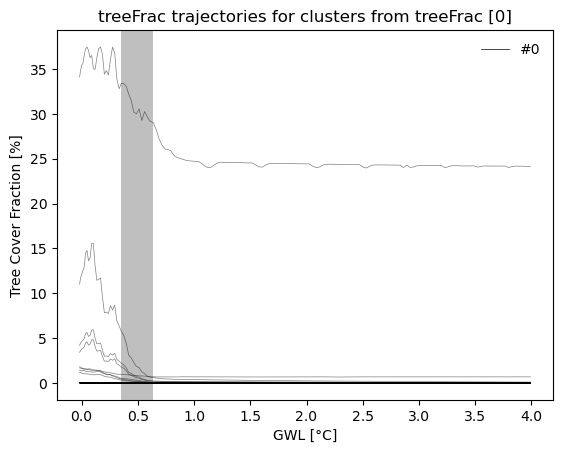

In [39]:
td.plot.timeseries(cluster_ids=[0, 1, 2]);